# Waffle House is overwhelmingly company-run, not franchised

**Finding:** Of the **2,006** Waffle House locations in this dataset, about
**94% (1,878) are company-operated** — run either by the parent company
(`WAFFLE HOUSE, INC`) or by one of its four wholly-owned subsidiaries. Only
about **6% (127) are franchises**. This is unusual for a large restaurant
chain, where franchising is the norm.

This notebook is the *editor test*: it documents the source, runs data-quality
checks, then reproduces the breakdown step-by-step from the raw file with a
chart, and ends with limitations. Run it top to bottom
(`Kernel → Restart & Run All`) to verify the claim from scratch.


## Data source

- **File:** `waffle_houses.csv` — a point-in-time export of Waffle House store
  locations (one row per location).
- **Key column:** `Operated By` — the operating entity for each location.
- **Full column documentation:** see [`DATA_DICTIONARY.md`](DATA_DICTIONARY.md).
- **Nature:** a snapshot. Counts reflect locations present in this export.


In [1]:
import pandas as pd

# Read as strings (per the data dictionary). The relevant column here is
# 'Operated By'; we leave it exactly as stored.
df = pd.read_csv("waffle_houses.csv", dtype=str)
print("shape:", df.shape)
df[["Store Code", "Business Name", "State", "Operated By"]].head()

shape: (2006, 14)


,Store Code,Business Name,State,Operated By
0,100,Waffle House #100,GA,"WAFFLE HOUSE, INC"
1,1000,Waffle House #1000,GA,"WAFFLE HOUSE, INC"
2,1001,Waffle House #1001,KY,"FULLY OWNED SUBSIDIARY: MIDWEST WAFFLES, INC."
3,1002,Waffle House #1002,OK,"WAFFLE HOUSE, INC"
4,1003,Waffle House #1003,MS,"WAFFLE HOUSE, INC"


## Quality checks (before trusting any number)

Before classifying, look at the raw `Operated By` values: how many distinct
values exist, how they are spelled, and whether any are blank. Categorization is
only as trustworthy as the field it is built from.


In [2]:
n = len(df)
print(f"Row count: {n}")

# Blank / missing operator values (NaN or empty after stripping whitespace)
blank = int(df["Operated By"].fillna("").str.strip().eq("").sum())
print(f"Blank 'Operated By' values: {blank}")

# Every distinct raw value and its frequency — this is the ground truth we
# build the categories from.
print(f"\nDistinct 'Operated By' values: {df['Operated By'].nunique(dropna=True)}")
print(df["Operated By"].value_counts(dropna=False).to_string())

Row count: 2006
Blank 'Operated By' values: 1

Distinct 'Operated By' values: 15
Operated By
WAFFLE HOUSE, INC                                   1251
FULLY OWNED SUBSIDIARY: EAST COAST WAFFLES, INC.     212
FULLY OWNED SUBSIDIARY: MID SOUTH WAFFLES, INC.      169
FULLY OWNED SUBSIDIARY: MIDWEST WAFFLES, INC.        143
FULLY OWNED SUBSIDIARY: OZARK WAFFLES, LLC.          103
FRANCHISE : ROCKY TOP WAFFLES                         37
FRANCHISE : LOOKOUT WAFFLES                           23
FRANCHISE : J. THOMAS & CO., INC.                     19
FRANCHISE : CHOO-CHOO WAFFLES                         18
FRANCHISE : YOGI HILL CORPORATION                     12
FRANCHISE : M & M WAFFLES, LLC.                        6
FRANCHISE : HILLTOP FOODS, LLC.                        5
FRANCHISE : AMARILLO WAFFLES, LLC.                     4
FRANCHISE : LEHIGH VALLEY WAFFLES, INC.                2
FRANCHISE : D.LOVE'S RESTAURANTS,LLC.                  1
NaN                                                 

**Note the spelling inconsistency** an editor would want flagged: subsidiaries
are prefixed `FULLY OWNED SUBSIDIARY:` (no space before the colon) while
franchises are prefixed `FRANCHISE :` (space before the colon). We therefore
classify on the **prefix**, not on exact punctuation.


## Reproduce the finding, step by step

Map each raw `Operated By` value to one of four operator types using its prefix,
then count and compute shares.


In [3]:
def operator_type(v):
    v = "" if pd.isna(v) else str(v).strip()
    if v == "":
        return "Unknown/blank"
    if v == "WAFFLE HOUSE, INC":
        return "Corporate"
    if v.startswith("FULLY OWNED SUBSIDIARY"):
        return "Subsidiary"
    if v.startswith("FRANCHISE"):
        return "Franchise"
    return "Other"

df["operator_type"] = df["Operated By"].apply(operator_type)

counts = df["operator_type"].value_counts()
order = ["Corporate", "Subsidiary", "Franchise", "Unknown/blank"]
counts = counts.reindex([c for c in order if c in counts.index])

total = len(df)
print("Operator type breakdown:")
for t, c in counts.items():
    print(f"  {t:14}: {c:5}  ({100*c/total:.1f}%)")

company_run = int(counts.get("Corporate", 0) + counts.get("Subsidiary", 0))
franchised = int(counts.get("Franchise", 0))
print(f"\nCompany-operated (Corporate + Subsidiary): {company_run} / {total} = {100*company_run/total:.1f}%")
print(f"Franchised:                                {franchised} / {total} = {100*franchised/total:.1f}%")

Operator type breakdown:
  Corporate     :  1251  (62.4%)
  Subsidiary    :   627  (31.3%)
  Franchise     :   127  (6.3%)
  Unknown/blank :     1  (0.0%)

Company-operated (Corporate + Subsidiary): 1878 / 2006 = 93.6%
Franchised:                                127 / 2006 = 6.3%


**Sanity check** — the four categories must account for every row (no value
falls through to "Other"), so the parts sum to the whole.


In [4]:
assert df["operator_type"].eq("Other").sum() == 0, "an Operated By value did not match any known prefix"
assert int(counts.sum()) == total, "category counts do not sum to the total"
print(f"OK: {int(counts.sum())} categorized rows == {total} total rows; no unclassified values.")

OK: 2006 categorized rows == 2006 total rows; no unclassified values.


## Chart: who operates Waffle House locations


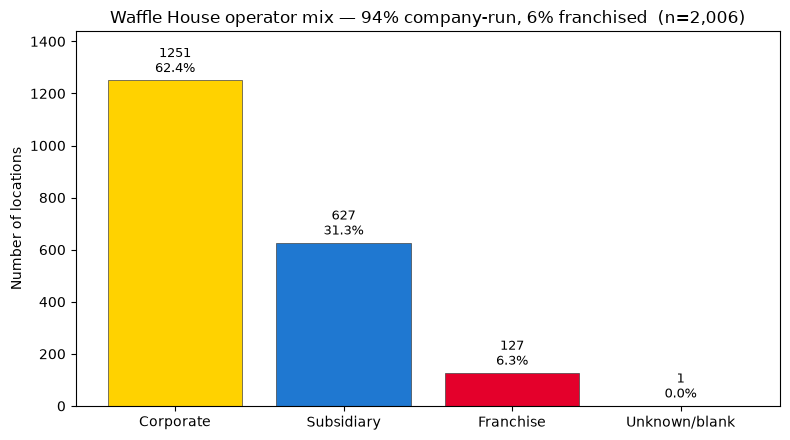

In [5]:
import matplotlib.pyplot as plt

WH_YELLOW, BLUE, RED, GRAY = "#FFD200", "#1f78d1", "#e4002b", "#cfccc4"
color_map = {"Corporate": WH_YELLOW, "Subsidiary": BLUE,
             "Franchise": RED, "Unknown/blank": GRAY}
colors = [color_map[t] for t in counts.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="#444", linewidth=0.5)
ax.set_ylabel("Number of locations")
ax.set_title(f"Waffle House operator mix — {100*company_run/total:.0f}% company-run, "
             f"{100*franchised/total:.0f}% franchised  (n={total:,})")
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, c + 15, f"{c}\n{100*c/total:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Limitations

- **Snapshot, not a census.** Counts reflect locations present in *this* export,
  not live or historical ownership.
- **Categories are inferred from a text field.** We classify on the prefix of
  `Operated By`; the inconsistent punctuation (`FULLY OWNED SUBSIDIARY:` vs.
  `FRANCHISE :`) is handled, but any future spelling change could require
  updating the rule. The sanity check above guards against silent misses.
- **"Company-operated" groups corporate + wholly-owned subsidiaries.** Both are
  owned by the parent; if you define "company-run" as the parent entity only,
  the figure is the Corporate share (~62%) instead of ~94%.
- **One blank value** (the Waffle House Museum row) is counted as Unknown; it is
  a non-restaurant outlier and does not affect the headline.
- **Location counts, not revenue or traffic.** This measures how stores are
  operated, not their sales or size.
